In [17]:
# all imports necessary
import numpy as np
# just to download the fashion_mnist and mnist datasets
from keras.datasets import fashion_mnist , mnist
import matplotlib.pyplot as plt
# to use wandb for logging the metrics
import os
import wandb
# for confusion matrix plotting
from sklearn.metrics import confusion_matrix
import seaborn as sns

### Question 1 - to downlaod the fashion_mnist dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


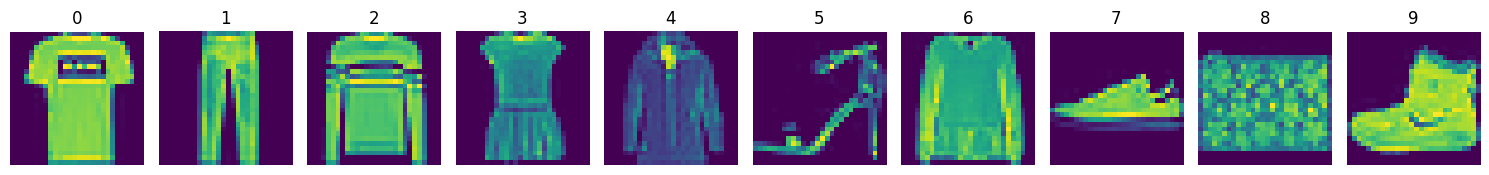

In [3]:
# downloaded the fashion_mnist dataset using keras and viewed the data shape and images

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()    # dividing between train and test for training later

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# to show the images of all 10 classes
fig, axes = plt.subplots(1,10, figsize=(15,3))
for i in range(10):
    axes[i].imshow(x_train[y_train==i][0])
    axes[i].set_xlabel(f'Label: {y_train[y_train == i][0]}')
    axes[i].set_title(i)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

From the paper by Han Xiao et al. "Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms"
- 0 T-Shirt/Top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandals
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boots

### Question 2 - Configure a neural network

I implemented a modular NeuralNetwork class focusing on flexibility and modularity. One can easily tweak the depth and number of neurons per hidden layer by adjusting a simple list (e.g., [128, 64, 32]).
The architecture uses a dictionary-based lookup for activations, so switching between ReLU, Tanh, or Sigmoid or adding new ones in the future takes just a single line of code
Similarly, the loss computation is kept modular so other loss functions can be plugged in later. 
The network ends with a Softmax layer for class probabilities and caches intermediate states during forward() to make backprop and optimization straightforward.

In [4]:
# activation functions and their derivates

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(np.clip(x, -500, 500))

def tanh_derivative(x):
    t = tanh(x)
    return 1.0 - (t ** 2)

def softmax(x):
    # subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    probs = exp_x / np.sum(exp_x, axis=-1, keepdims=True)
    return np.clip(probs, 1e-15, 1.0 - 1e-15)

# central lookup map for activations and gradients
ACTIVATIONS = {
    "relu": (relu, relu_derivative),
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh": (tanh, tanh_derivative)
}


def cross_entropy_loss(y_hat, y):
    m = y.shape[0]
    eps = 1e-15
    # clip probabilities to avoid log(0) numerical instability
    y_hat_clipped = np.clip(y_hat, eps, 1.0 - eps)
    # mean cross-entropy loss
    loss = -np.mean(np.log(y_hat_clipped[np.arange(m), y]))
    # compute gradient of loss w.r.t. logits (dZ_out)
    y_one_hot = np.zeros_like(y_hat)
    y_one_hot[np.arange(m), y] = 1.0
    dZ_out = (y_hat - y_one_hot) / m
    
    return loss, dZ_out
    

class NeuralNetwork:
    def __init__(self, input_size=784, hidden_sizes=[128, 64, 32], output_size=10, activation="relu", weight_init="random"):
        self.layer_dims = [input_size] + hidden_sizes + [output_size]

        act = activation.lower()
        if act not in ACTIVATIONS:
            raise ValueError(f"Unsupported activation '{activation}'. Choose from {list(ACTIVATIONS.keys())}")
        self.act_fn, self.act_grad = ACTIVATIONS[act]

        self.weights = []
        self.biases = []

        init_mode = weight_init.lower()
        
        for din, dout in zip(self.layer_dims[:-1], self.layer_dims[1:]):
            # chosing weight initialization method
            if init_mode in ["xavier", "glorot"]:
                limit = np.sqrt(6.0 / (din + dout))
                W = np.random.uniform(-limit, limit, size=(din, dout))
            else:
                # random initialization
                W = np.random.randn(din, dout) * 0.01

            b = np.zeros((1, dout))
            self.weights.append(W)
            self.biases.append(b)

    
    def forward(self, X):
        A_list, H_list = [], [X]
        H = X
        
        # hidden layers (chosen activation)
        for W, b in zip(self.weights[:-1], self.biases[:-1]):
            A = np.dot(H, W) + b
            H = self.act_fn(A)
            A_list.append(A)
            H_list.append(H)
        
        # output layer (Softmax)
        A_out = np.dot(H, self.weights[-1]) + self.biases[-1]
        y_hat = softmax(A_out)
        
        A_list.append(A_out)
        H_list.append(y_hat)
        return y_hat, A_list, H_list

    def get_params(self):
        # flattened list of [W0, b0, W1, b1, ...] for optimizers
        params = []
        for W, b in zip(self.weights, self.biases):
            params.extend([W, b])
        return params
    
    def backward(self, dZ_out, A_list, H_list):
        dW_list, db_list = [], []
        dZ = dZ_out

        for i in reversed(range(len(self.weights))):
            H_prev = H_list[i]

            # gradients for current layer
            dW = np.dot(H_prev.T, dZ)
            db = np.sum(dZ, axis=0, keepdims=True)
            dW_list.insert(0, dW)
            db_list.insert(0, db)

            # remaining error to propagate backward
            if i > 0:
                dH_prev = np.dot(dZ, self.weights[i].T)
                dZ = dH_prev * self.act_grad(A_list[i-1])

        # flatten to match self.get_params() order
        grads = []
        for dW, db in zip(dW_list, db_list):
            grads.extend([dW, db])
        return grads

##### Sanity check: Running a forward pass on the training data

In [5]:
# flattening images to 784-d vectors and scale pixel values to [0, 1]
X_train = x_train.reshape(len(x_train), -1) / 255.0
X_test = x_test.reshape(len(x_test), -1) / 255.0

# initializing default 3-layer test model
model = NeuralNetwork(
    input_size=784, 
    hidden_sizes=[128, 64, 32], 
    output_size=10, 
    activation="relu",
    weight_init="xavier"
)
# model = NeuralNetwork(
#     input_size=784, 
#     hidden_sizes=[128, 64, 32], 
#     output_size=10, 
#     activation="tanh",
#     weight_init="random"
# )

probs, A_cache, H_cache = model.forward(X_train)

# verifying output dimensions and probability distribution
print(f"Output shape: {probs.shape}")
print(f"Sample 0 class probabilities:\n{np.round(probs[0], 4)}")
print(f"Probability sum check: {probs[0].sum():.6f}")

Output shape: (60000, 10)
Sample 0 class probabilities:
[0.1798 0.0565 0.2068 0.0376 0.0662 0.1915 0.0661 0.0571 0.0953 0.0432]
Probability sum check: 1.000000


### Question 3 - Backpropagation

I have implemented all the optimizers present in the assignment sgd, momentum-based gradient descent, Nesterov accelerated gradient descent, rmsprop, adam, nadam.
In order to add any other optimzer like Eve is straightforward. One simply creates a class inheriting from Adam or Optimizer, initializes additional state buffers, and computes parameter updates inside _update() without altering any network or backprop code.

In [6]:
# helper to mirror parameter list shapes with zeros
def zeros_like_params(params):
    return [np.zeros_like(p) for p in params]

# base optimizer class
class Optimizer:
    def __init__(self, lr=0.001):
        self.lr = lr

    def initialize(self, params):
        pass  

    def step(self, params, grads):
        for i, (p, g) in enumerate(zip(params, grads)):
            g_clean = np.nan_to_num(g, nan=0.0, posinf=5.0, neginf=-5.0)
            g_clipped = np.clip(g_clean, -5.0, 5.0)
            self._update(i, p, g_clipped)

    def _update(self, i, p, g):
        raise NotImplementedError

# SGD optimizer class
class SGD(Optimizer):
    def _update(self, i, p, g):
        p -= self.lr * g

# Momentum optimizer class
class Momentum(Optimizer):
    def __init__(self, lr=0.001, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum

    def initialize(self, params):
        self.velocity = zeros_like_params(params)

    def _update(self, i, p, g):
        self.velocity[i] = self.momentum * self.velocity[i] - self.lr * g
        p += self.velocity[i]

# Nesterov Accelerated Gradient (NAG) optimizer class
class NAG(Momentum):
    def _update(self, i, p, g):
        v_prev = self.velocity[i]
        self.velocity[i] = self.momentum * v_prev - self.lr * g
        # Look-ahead update step
        p += -self.momentum * v_prev + (1.0 + self.momentum) * self.velocity[i]

# RMSProp optimizer class 
class RMSProp(Optimizer):
    def __init__(self, lr=0.001, beta=0.9, eps=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.eps = eps

    def initialize(self, params):
        self.sq_grad = zeros_like_params(params)

    def _update(self, i, p, g):
        self.sq_grad[i] = self.beta * self.sq_grad[i] + (1.0 - self.beta) * (g ** 2)
        p -= self.lr * g / (np.sqrt(self.sq_grad[i]) + self.eps)

# Adam optimizer class
class Adam(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def initialize(self, params):
        self.m = zeros_like_params(params)
        self.v = zeros_like_params(params)
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        super().step(params, grads)

    def _update(self, i, p, g):
        self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
        self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g ** 2)
        
        # bias corrections
        m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
        v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)

        denom = np.sqrt(np.maximum(v_hat, 0.0)) + self.eps
        p -= self.lr * m_hat / denom

# Nadam optimizer class (Adam with Nesterov momentum)
class Nadam(Adam):
    def _update(self, i, p, g):
        self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
        self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g ** 2)
        
        # Nesterov-accelerated bias-corrected momentum
        m_hat = (self.beta1 * self.m[i] / (1.0 - self.beta1 ** self.t)) + \
                ((1.0 - self.beta1) * g / (1.0 - self.beta1 ** self.t))
        v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)
        
        denom = np.sqrt(np.maximum(v_hat, 0.0)) + self.eps
        p -= self.lr * m_hat / denom

We can easily change the number of epochs and batch size by changing the value of EPOCHS and BATCH_SIZE which are defined globally.

In [7]:
EPOCHS = 10
BATCH_SIZE = 64
SEED = 42

# held out 10% of the training data for validation (54,000 train / 6,000 val)
X_tr, y_tr = X_train[:54000], y_train[:54000]
X_val, y_val = X_train[54000:], y_train[54000:]


def train(model, opt):
    params = model.get_params()
    opt.initialize(params)
    rng = np.random.default_rng(SEED)

    for epoch in range(1, EPOCHS + 1):
        order = rng.permutation(len(X_tr))
        total_loss = 0.0

        for s in range(0, len(order), BATCH_SIZE):
            batch_idx = order[s:s + BATCH_SIZE]
            y_hat, A_list, H_list = model.forward(X_tr[batch_idx])
            loss, dZ = cross_entropy_loss(y_hat, y_tr[batch_idx])
            
            grads = model.backward(dZ, A_list, H_list)
            opt.step(params, grads)
            
            total_loss += loss * len(batch_idx)

        # post-epoch validation check
        val_hat, _, _ = model.forward(X_val)
        val_loss, _ = cross_entropy_loss(val_hat, y_val)
        val_acc = (val_hat.argmax(axis=1) == y_val).mean()
        
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {total_loss / len(order):.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return val_acc


# compare optimizers with tuned learning rates
optimizers = {
    "SGD": SGD(lr=0.1),
    "Momentum": Momentum(lr=0.01, momentum=0.9),
    "NAG": NAG(lr=0.01, momentum=0.9),
    "RMSProp": RMSProp(lr=0.001),
    "Adam": Adam(lr=0.001),
    "Nadam": Nadam(lr=0.001),
}

results = {}
for name, opt in optimizers.items():
    print(f"\n--- Running {name} ---")
    np.random.seed(SEED)
    model = NeuralNetwork(input_size=784, hidden_sizes=[128, 64, 32], output_size=10)
    results[name] = train(model, opt)

print("\n--- Final Validation Benchmarks ---")
for name, acc in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{name:<12}: {acc:.4f}")


--- Running SGD ---
Epoch  1/10 | Train Loss: 2.3030 | Val Loss: 2.3033 | Val Acc: 0.0925
Epoch  2/10 | Train Loss: 2.3018 | Val Loss: 2.2795 | Val Acc: 0.1363
Epoch  3/10 | Train Loss: 1.3940 | Val Loss: 0.9259 | Val Acc: 0.6128
Epoch  4/10 | Train Loss: 0.7113 | Val Loss: 0.6202 | Val Acc: 0.7612
Epoch  5/10 | Train Loss: 0.5291 | Val Loss: 0.5692 | Val Acc: 0.7903
Epoch  6/10 | Train Loss: 0.4412 | Val Loss: 0.4242 | Val Acc: 0.8510
Epoch  7/10 | Train Loss: 0.3989 | Val Loss: 0.4180 | Val Acc: 0.8535
Epoch  8/10 | Train Loss: 0.3736 | Val Loss: 0.3853 | Val Acc: 0.8668
Epoch  9/10 | Train Loss: 0.3507 | Val Loss: 0.3816 | Val Acc: 0.8635
Epoch 10/10 | Train Loss: 0.3355 | Val Loss: 0.3575 | Val Acc: 0.8752

--- Running Momentum ---
Epoch  1/10 | Train Loss: 2.3030 | Val Loss: 2.3033 | Val Acc: 0.0925
Epoch  2/10 | Train Loss: 2.3022 | Val Loss: 2.2928 | Val Acc: 0.1112
Epoch  3/10 | Train Loss: 1.3941 | Val Loss: 1.0100 | Val Acc: 0.6060
Epoch  4/10 | Train Loss: 0.6570 | Val Loss

### Question 4 - Hyperparameter sweep with wandb

Weights & Biases (W&B) Sweeps supports three core search methods (grid, random, and bayesian) to automate hyperparameter optimization, alongside advanced early stopping algorithms like hyperband to efficiently prune underperforming runs. (Source: Google)

So, I chose Bayesian Optimization paired with Hyperband early stopping for the hyperparameter search. Grid Search was computationally unfeasible due to the exponential number of parameter combinations, and Random Search does not leverage historical run performance. 

The Bayesian method constructs a probabilistic model to actively sample high-performing regions of the hyperparameter space. Hyperband further improves efficiency by benchmarking runs at early epochs and pruning underperforming configurations, allowing the sweep to explore more candidate configurations within the budget.

In [8]:
os.environ["WANDB_SILENT"] = "true"
TOTAL_RUNS = 100
RUN_COUNT = 0

OPTIMIZERS = {
    "sgd": SGD, 
    "momentum": Momentum, 
    "nesterov": NAG,
    "rmsprop": RMSProp, 
    "adam": Adam, 
    "nadam": Nadam
}

# hyperparameter sweep configuration for Wandb
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "early_terminate": {"type": "hyperband", "min_iter": 3},
    "parameters": {
        "epochs":        {"values": [5, 10]},
        "num_layers":    {"values": [3, 4, 5]},
        "hidden_size":   {"values": [32, 64, 128]},
        "weight_decay":  {"values": [0, 0.0005, 0.5]},
        "learning_rate": {"values": [1e-3, 1e-4]},
        "optimizer":     {"values": ["sgd", "momentum", "nesterov", "rmsprop", "adam", "nadam"]},
        "batch_size":    {"values": [16, 32, 64]},
        "weight_init":   {"values": ["random", "Xavier"]},
        "activation":    {"values": ["sigmoid", "tanh", "relu"]},
    },
}

def sweep_train():
    global RUN_COUNT
    RUN_COUNT += 1

    # silencing invalid value warnings from numpy
    np.seterr(all='ignore')

    # to handle hyperband pruning, which stops a run by raising a bare Exception with no message
    try:
        wandb.init()
        cfg = wandb.config

        # formatted run name for Wandb UI dashboard
        wandb.run.name = f"run{RUN_COUNT}_{cfg.optimizer}_hl{cfg.num_layers}_sz{cfg.hidden_size}_{cfg.activation}_{cfg.weight_init}_bs{cfg.batch_size}_lr{cfg.learning_rate}_wd{cfg.weight_decay}"

        # initialize model architecture and optimizer
        model = NeuralNetwork(
            input_size=784, 
            hidden_sizes=[cfg.hidden_size] * cfg.num_layers, 
            output_size=10,
            activation=cfg.activation, 
            weight_init=cfg.weight_init
        )
        
        params = model.get_params()
        opt = OPTIMIZERS[cfg.optimizer](lr=cfg.learning_rate)
        opt.initialize(params)
        
        rng = np.random.default_rng()
        diverged = False

        for epoch in range(1, cfg.epochs + 1):
            order = rng.permutation(len(X_tr))
            train_loss, train_correct = 0.0, 0

            # mini-batch training loop
            for s in range(0, len(order), cfg.batch_size):
                batch_idx = order[s:s + cfg.batch_size]
                
                y_hat, A_list, H_list = model.forward(X_tr[batch_idx])
                loss, dZ = cross_entropy_loss(y_hat, y_tr[batch_idx])
                grads = model.backward(dZ, A_list, H_list)

                # apply weight decay to weights only
                if cfg.weight_decay > 0:
                    for i in range(0, len(grads), 2):
                        grads[i] += cfg.weight_decay * params[i]

                opt.step(params, grads)
                
                train_loss += loss * len(batch_idx)
                train_correct += (y_hat.argmax(axis=1) == y_tr[batch_idx]).sum()

            # validation pass
            val_hat, _, _ = model.forward(X_val)
            val_loss, _ = cross_entropy_loss(val_hat, y_val)
            val_acc = (val_hat.argmax(axis=1) == y_val).mean()

            # check if the model has diverged
            diverged = not (np.isfinite(val_loss) and np.isfinite(train_loss))
            val_loss = float(np.nan_to_num(val_loss, nan=1e3, posinf=1e3, neginf=1e3))
            train_loss = float(np.nan_to_num(train_loss, nan=1e3, posinf=1e3, neginf=1e3))

            # log epoch metrics to Wandb
            wandb.log({
                "epoch": epoch,
                "loss": train_loss / len(order),
                "accuracy": train_correct / len(order),
                "val_loss": val_loss,
                "val_acc": val_acc
            })

            # no point burning the remaining epochs on a dead network
            if diverged:
                print(f"Run {RUN_COUNT}/{TOTAL_RUNS} [{cfg.optimizer}] diverged at epoch {epoch} - stopped early")
                break

        # simple summary line printed only once per completed sweep run
        if not diverged:
            print(f"Run {RUN_COUNT}/{TOTAL_RUNS} [{cfg.optimizer}] finished - Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

    except Exception as e:
        # a bare Exception with no message is the hyperband prune
        detail = f": {type(e).__name__}: {e}" if str(e) else " - pruned by hyperband"
        print(f"Run {RUN_COUNT}/{TOTAL_RUNS} stopped{detail}")

# execute sweep
# wandb.login(key="wand_api_key")  
sweep_id = wandb.sweep(sweep_config, project="fashion-mnist-sweep")
wandb.agent(sweep_id, sweep_train, count=TOTAL_RUNS)

Create sweep with ID: ppb5y8u4
Sweep URL: https://wandb.ai/trishab/fashion-mnist-sweep/sweeps/ppb5y8u4
Run 1/100 [sgd] finished - Val Acc: 0.0925 | Val Loss: 2.3028
Run 2/100 [sgd] finished - Val Acc: 0.0942 | Val Loss: 2.3026
Run 3/100 [nesterov] finished - Val Acc: 0.1008 | Val Loss: 2.3027
Run 4/100 [rmsprop] finished - Val Acc: 0.8570 | Val Loss: 0.3957
Run 5/100 [nesterov] finished - Val Acc: 0.0925 | Val Loss: 2.3028
Run 6/100 [adam] finished - Val Acc: 0.0925 | Val Loss: 2.3028
Run 7/100 [rmsprop] finished - Val Acc: 0.0973 | Val Loss: 2.3028
Run 8/100 [momentum] finished - Val Acc: 0.0942 | Val Loss: 2.3028
Run 9/100 [adam] finished - Val Acc: 0.1008 | Val Loss: 2.3034
Run 10/100 [nadam] finished - Val Acc: 0.8683 | Val Loss: 0.3800
Run 11/100 [sgd] finished - Val Acc: 0.0925 | Val Loss: 2.3027
Run 12/100 [nadam] finished - Val Acc: 0.1003 | Val Loss: 2.3027
Run 13/100 [nadam] finished - Val Acc: 0.0925 | Val Loss: 2.3028
Run 14/100 [nadam] finished - Val Acc: 0.8397 | Val Loss

### Question 5 and Question 6

Graphs are attached in the pdf as assignment1_wandb.pdf. https://wandb.ai/trishab/fashion-mnist-sweep/reports/Final-Report--VmlldzoxNzY3NzM3Ng
Observation:
- Adam, Nadam, and RMSProp(Adaptive optimizers) easily pass 85% accuracy, whereas plain SGD consistently have poor performance due to slow convergence.
- A high weight decay of 0.5 over-regularizes the network and shows up as the single biggest driver of poor accuracy on the correlation chart. 
- Sigmoid activations cause severe vanishing gradients across multiple hidden layers, whereas ReLU maintains steady gradient flow.
- Standard small random initialization frequently stalls out early, while Xavier initialization consistently yields top validation scores.


Recommended Best Configuration:
- Optimizer: Adam or Nadam (lr = 0.001)
- Activation & Init: ReLU with Xavier initialization
- Regularization: Zero or light weight decay (0 or 0.0005)
- Architecture: 3 hidden layers with batch size 32 or 64

### Question 7 - Confusion matrix

Best Run Config: run89_rmsprop_hl3_sz64_tanh_Xavier_bs64_lr0.001_wd0 | Val Acc: 0.8857 | Val Loss: 0.3297
Epoch  1/10 | Train Loss: 0.5204
Epoch  2/10 | Train Loss: 0.3853
Epoch  3/10 | Train Loss: 0.3494
Epoch  4/10 | Train Loss: 0.3283
Epoch  5/10 | Train Loss: 0.3109
Epoch  6/10 | Train Loss: 0.2970
Epoch  7/10 | Train Loss: 0.2832
Epoch  8/10 | Train Loss: 0.2739
Epoch  9/10 | Train Loss: 0.2665
Epoch 10/10 | Train Loss: 0.2569
Test Accuracy: 0.8761


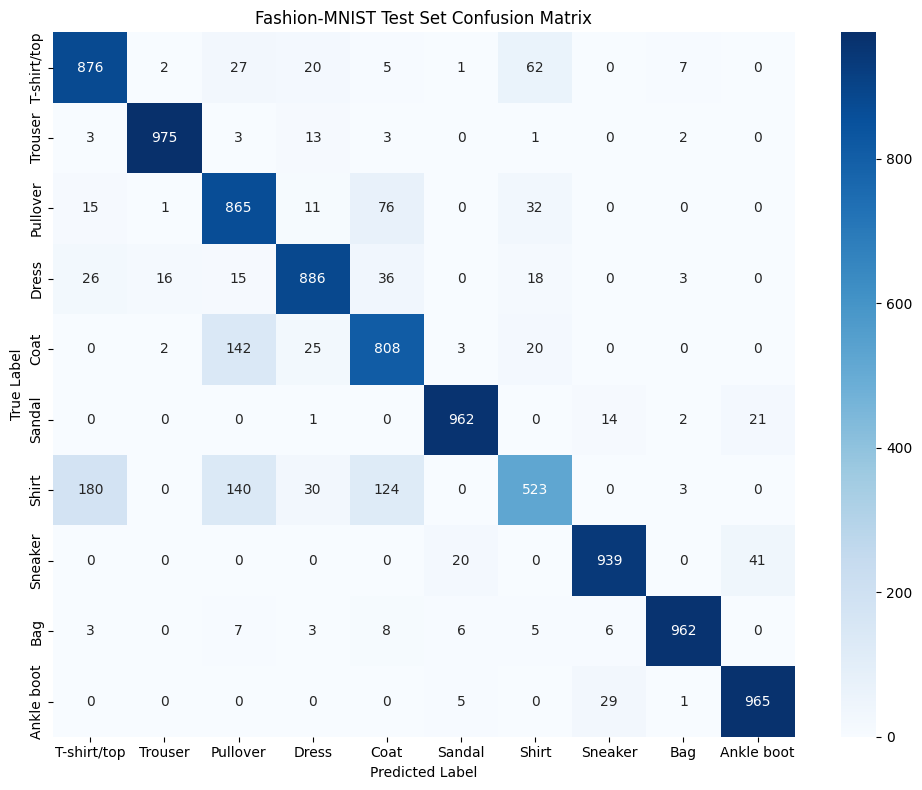

In [12]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

api = wandb.Api()
sweep = api.sweep("trishab/fashion-mnist-sweep/sweeps/ppb5y8u4")
best = sweep.best_run()
cfg = best.config

print(f"Best Run Config: {best.name} | Val Acc: {best.summary['val_acc']:.4f} | Val Loss: {best.summary['val_loss']:.4f}")

# retraining on full training data with best hyperparameters
np.random.seed(42)
final_model = NeuralNetwork(
    input_size=784,
    hidden_sizes=[cfg["hidden_size"]] * cfg["num_layers"],
    output_size=10,
    activation=cfg["activation"],
    weight_init=cfg["weight_init"]
)

opt = OPTIMIZERS[cfg["optimizer"]](lr=cfg["learning_rate"])
params = final_model.get_params()
opt.initialize(params)
rng = np.random.default_rng(42)

for epoch in range(1, cfg["epochs"] + 1):
    order = rng.permutation(len(X_train))
    total_loss = 0.0
    for s in range(0, len(order), cfg["batch_size"]):
        idx = order[s:s + cfg["batch_size"]]
        y_hat, A, H = final_model.forward(X_train[idx])
        loss, dZ = cross_entropy_loss(y_hat, y_train[idx])
        grads = final_model.backward(dZ, A, H)
        
        if cfg["weight_decay"] > 0:
            for i in range(0, len(grads), 2):
                grads[i] += cfg["weight_decay"] * params[i]
                
        opt.step(params, grads)
        total_loss += loss * len(idx)

    print(f"Epoch {epoch:2d}/{cfg['epochs']} | Train Loss: {total_loss / len(order):.4f}")

probs, _, _ = final_model.forward(X_test)
y_pred = probs.argmax(axis=1)
test_acc = (y_pred == y_test).mean()
print(f"Test Accuracy: {test_acc:.4f}")

# confusion matrix assembly via numpy
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Test Set Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

We can see from the confusion matrix that the Pullover, Coat, Shirt, and T-shirt classes are the most frequently misclassified, as their visual features tend to look very similar. The model also occasionally struggles to distinguish between Ankle Boots and Sneakers for the same reason.

### Question 8 - using MSE loss

In [13]:
def mse_loss(y_hat, y):
    m = y.shape[0]
    y_one_hot = np.zeros_like(y_hat)
    y_one_hot[np.arange(m), y] = 1.0
    loss = 0.5 * np.mean(np.sum((y_hat - y_one_hot) ** 2, axis=1))
    e = y_hat - y_one_hot
    sum_e_yhat = np.sum(e * y_hat, axis=1, keepdims=True)
    dZ = (e * y_hat - y_hat * sum_e_yhat) / m

    return loss, dZ

--- Training with Cross-Entropy Loss ---
Epoch  1/10 | Val Acc: 0.8447
Epoch  2/10 | Val Acc: 0.8667
Epoch  3/10 | Val Acc: 0.8618
Epoch  4/10 | Val Acc: 0.8575
Epoch  5/10 | Val Acc: 0.8792
Epoch  6/10 | Val Acc: 0.8743
Epoch  7/10 | Val Acc: 0.8685
Epoch  8/10 | Val Acc: 0.8847
Epoch  9/10 | Val Acc: 0.8793
Epoch 10/10 | Val Acc: 0.8817
--- Training with MSE Loss ---
Epoch  1/10 | Val Acc: 0.8398
Epoch  2/10 | Val Acc: 0.8672
Epoch  3/10 | Val Acc: 0.8607
Epoch  4/10 | Val Acc: 0.8613
Epoch  5/10 | Val Acc: 0.8775
Epoch  6/10 | Val Acc: 0.8765
Epoch  7/10 | Val Acc: 0.8687
Epoch  8/10 | Val Acc: 0.8870
Epoch  9/10 | Val Acc: 0.8758
Epoch 10/10 | Val Acc: 0.8823
Cross-Entropy Test Accuracy : 87.37%
MSE Loss Test Accuracy      : 87.38%


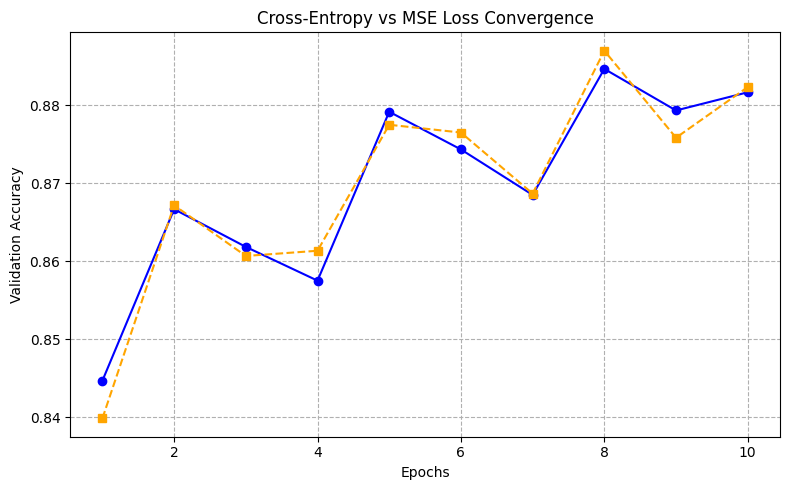

In [16]:
# winning Hyperparameters from Run 89
hidden_sizes = [cfg["hidden_size"]] * cfg["num_layers"]  # 3 hidden layers of 64 units
act = cfg["activation"]                                  # tanh
init = cfg["weight_init"]                                # Xavier
lr = cfg["learning_rate"]                                # 0.001
bs = cfg["batch_size"]                                  # 64
opt_name = cfg["optimizer"]                              # rmsprop
epochs = 10


history = {
    "Cross-Entropy": {"val_acc": [], "test_acc": 0.0},
    "MSE": {"val_acc": [], "test_acc": 0.0}
}

loss_functions = [
    ("Cross-Entropy", cross_entropy_loss),
    ("MSE", mse_loss)
]


for loss_type, loss_fn in loss_functions:
    print(f"--- Training with {loss_type} Loss ---")
    
    np.random.seed(42)
    model = NeuralNetwork(784, hidden_sizes, 10, act, init)
    opt = OPTIMIZERS[opt_name](lr=lr)
    params = model.get_params()
    opt.initialize(params)

    rng = np.random.default_rng(42)

    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(X_tr))
        
        for s in range(0, len(order), bs):
            idx = order[s:s + bs]
            y_hat, A, H = model.forward(X_tr[idx])
            loss, dZ = loss_fn(y_hat, y_tr[idx])
            grads = model.backward(dZ, A, H)
            opt.step(params, grads)

        # validation evaluation
        val_hat, _, _ = model.forward(X_val)
        val_acc = (val_hat.argmax(axis=1) == y_val).mean()
        history[loss_type]["val_acc"].append(val_acc)
        print(f"Epoch {epoch:2d}/{epochs} | Val Acc: {val_acc:.4f}")

    # final test evaluation
    test_hat, _, _ = model.forward(X_test)
    test_acc = (test_hat.argmax(axis=1) == y_test).mean()
    history[loss_type]["test_acc"] = test_acc


print(f"Cross-Entropy Test Accuracy : {history['Cross-Entropy']['test_acc'] * 100:.2f}%")
print(f"MSE Loss Test Accuracy      : {history['MSE']['test_acc'] * 100:.2f}%")



epoch_axis = np.arange(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_axis, history["Cross-Entropy"]["val_acc"], "o-", label="Cross-Entropy Loss", color="blue")
plt.plot(epoch_axis, history["MSE"]["val_acc"], "s--", label="Mean Squared Error (MSE)", color="orange")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Cross-Entropy vs MSE Loss Convergence")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

Observations:

- Both Cross-Entropy and MSE reach almost identical final test accuracy ~ 87% on Fashion-MNIST when paired with an adaptive optimizer
like RMSProp and Xavier initialization.
- Adaptive optimizers scale step sizes dynamically using moving averages of past squared gradients, which counteracts the gradient-vanishing effect caused by MSE's y_hat(1-y_hat) term.

I would still chose CE over MSE because:

- Cross-Entropy's gradient simplifies directly to (y_hat-y), giving a strong learning signal even when predictions are far off. MSE includes an extra y_hat(1-y_hat) factor that shrinks gradients toward zero when predictions are confident but wrong.
- Softmax + Cross-Entropy guarantees a convex loss surface with respect to logits, making optimization fast and predictable without relying strictly on complex adaptive optimizers.
- Cross-Entropy models categorical probability distributions directly, whereas MSE implicitly assumes continuous Gaussian noise, which is ill-suited for classification targets.

### Question 10
Standard MNIST (handwritten digits) is visually simpler than Fashion-MNIST, the core architecture transferred from Fashion-MNIST will comfortably achieve high accuracy on MNIST because of its simplicity

The recommended configurations would be 
- Config 1 Optimizer as RMSProp with 3 layers of 64 neurons. Activation as tanh with Xavier initialization. LR=0.001 and batch size=64.
Because it was the best sweep that won in fashion mnist.

- Config 2 Optimizer as Adam with 3 layers of 128 neurons. Activation as Relu with Xavier initialization. LR=0.001 and batch size=64.
Because adaptive ooptimzer outperformed and these configuration is fast and has reliable convergence

- Config 3 Optimizer as Nadam with deeper architecture 4 layers of 128 neurons. Activation as Relu with Xavier initialization. LR=0.001 and batch size=32. In order to test if extra depth captures finer digit strokes on MNIST.

In [18]:
(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
x_train_flattened = x_train_m.reshape(len(x_train_m), -1) / 255.0
x_test_flattened = x_test_m.reshape(len(x_test_m), -1) / 255.0

# 3 configuration for the MNIST dataset
configs = [
    {
            "name": "Config 1 (RMSProp + Tanh + 3x64)",
            "num_layers": 3, "hidden_size": 64, "activation": "tanh",
            "weight_init": "Xavier", "optimizer": "rmsprop", "lr": 0.001, "bs": 64
    },
    {
        "name": "Config 2 (Adam + ReLU + 3x128)",
        "num_layers": 3, "hidden_size": 128, "activation": "relu",
        "weight_init": "Xavier", "optimizer": "adam", "lr": 0.001, "bs": 64
    },
    
    {
        "name": "Config 3 (Nadam + ReLU + 4x128)",
        "num_layers": 4, "hidden_size": 128, "activation": "relu",
        "weight_init": "Xavier", "optimizer": "nadam", "lr": 0.001, "bs": 32
    }
]

mnist_results = []

for cfg in configs:
    print(f" Running {cfg['name']} on MNIST")
    np.random.seed(42)
    model = NeuralNetwork(
        input_size=784,
        hidden_sizes=[cfg["hidden_size"]] * cfg["num_layers"],
        output_size=10,
        activation=cfg["activation"],
        weight_init=cfg["weight_init"]
    )
    
    opt = OPTIMIZERS[cfg["optimizer"]](lr=cfg["lr"])
    params = model.get_params()
    opt.initialize(params)
    
    rng = np.random.default_rng(42)
    epochs = 10
    
    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(x_train_flattened))
        for s in range(0, len(order), cfg["bs"]):
            idx = order[s : s + cfg["bs"]]
            y_hat, A, H = model.forward(x_train_flattened[idx])
            loss, dZ = cross_entropy_loss(y_hat, y_train_m[idx])
            grads = model.backward(dZ, A, H)
            opt.step(params, grads)
            
    test_probs, _, _ = model.forward(x_test_flattened)
    test_pred = test_probs.argmax(axis=1)
    test_acc = (test_pred == y_test_m).mean()
    
    mnist_results.append({
        "Config": cfg["name"],
        "Test Accuracy": test_acc
    })
    print(f"{cfg['name']} Test Accuracy: {test_acc * 100:.2f}%")


for res in mnist_results:
    print(f"{res['Config']:<50}: {res['Test Accuracy']*100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 Running Config 1 (RMSProp + Tanh + 3x64) on MNIST
Config 1 (RMSProp + Tanh + 3x64) Test Accuracy: 97.49%
 Running Config 2 (Adam + ReLU + 3x128) on MNIST
Config 2 (Adam + ReLU + 3x128) Test Accuracy: 97.94%
 Running Config 3 (Nadam + ReLU + 4x128) on MNIST
Config 3 (Nadam + ReLU + 4x128) Test Accuracy: 97.38%
Config 1 (RMSProp + Tanh + 3x64)                  : 97.49%
Config 2 (Adam + ReLU + 3x128)                    : 97.94%
Config 3 (Nadam + ReLU + 4x128)                   : 97.38%
